In [15]:
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os
import scipy.io as sio
def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

########################################################################check SF3 in large scale ####################################
def sliding_window(total_length, window_size, step=1):
    """
    生成正确的滑动窗口切片（从0开始计数）
    """
    slices = []
    for start in range(0, total_length - window_size + 1, step):
        end = start + window_size - 1  # 结束索引是包含的
        slices.append((start, end))
    return slices
    
# 
from tqdm import tqdm
def check_SF3_largescale(u,v,xscale,total_length,window_size):
    
    # total_length = 287
    # window_size = 287
    step = 1
    slices = sliding_window(total_length, window_size, step)
    
    du=0
    dv=0
    SF3_L_tb=0
    SF3_T_tb=0
    SF3_L_lr=0
    SF3_T_lr=0
    for ii in tqdm(range(len(slices))):
        # print(f'{slices[ii][0]}{slices[ii][1]}')
        du=u[:,slices[ii][1],:]-u[:,slices[ii][0],:]
        dv=v[:,slices[ii][1],:]-v[:,slices[ii][0],:]
        SF3_L_tb=SF3_L_tb+dv**3
        SF3_T_tb=SF3_T_tb+dv*(du**2)
    
        du=u[:,:,slices[ii][1]]-u[:,:,slices[ii][0]]
        dv=v[:,:,slices[ii][1]]-v[:,:,slices[ii][0]]
        SF3_L_lr=SF3_L_lr+du**3
        SF3_T_lr=SF3_T_lr+du*(dv**2)
    
    SF3_L_tb=np.nanmean(SF3_L_tb/len(slices))
    SF3_T_tb=np.nanmean(SF3_T_tb/len(slices))
    SF3_L_lr=np.nanmean(SF3_L_lr/len(slices))
    SF3_T_lr=np.nanmean(SF3_T_lr/len(slices))
    R=xscale*window_size
    SF3_check=(SF3_L_tb+SF3_T_tb+SF3_L_lr+SF3_T_lr)/2
    return SF3_check, SF3_L_tb, SF3_T_tb, SF3_L_lr, SF3_T_lr,R


def check_SF1_largescale(u,v,xscale,total_length,window_size):
    
    # total_length = 287
    # window_size = 287
    step = 1
    slices = sliding_window(total_length, window_size, step)
    
    du=0
    dv=0
    SF1_L_tb=0
    SF1_T_tb=0
    SF1_L_lr=0
    SF1_T_lr=0
    for ii in tqdm(range(len(slices))):
        # print(f'{slices[ii][0]}{slices[ii][1]}')
        du=u[:,slices[ii][1],:]-u[:,slices[ii][0],:]
        dv=v[:,slices[ii][1],:]-v[:,slices[ii][0],:]
        SF1_L_tb=SF1_L_tb+dv
        SF1_T_tb=SF1_T_tb+du
    
        du=u[:,:,slices[ii][1]]-u[:,:,slices[ii][0]]
        dv=v[:,:,slices[ii][1]]-v[:,:,slices[ii][0]]
        SF1_L_lr=SF1_L_lr+du
        SF1_T_lr=SF1_T_lr+dv
    
    SF1_L_tb=np.nanmean(SF1_L_tb/len(slices))
    SF1_T_tb=np.nanmean(SF1_T_tb/len(slices))
    SF1_L_lr=np.nanmean(SF1_L_lr/len(slices))
    SF1_T_lr=np.nanmean(SF1_T_lr/len(slices))
    R=xscale*window_size
    SF1_L_check=(SF1_L_tb+SF1_L_lr)/2
    SF1_T_check=(SF1_T_tb+SF1_T_lr)/2
    return SF1_L_check, SF1_T_check,R

# check HF SF3

In [22]:
data_dir='/meddy/simingzhang/Data/RB_iceland_data/'
fname='iceland_wave/z_niskin2km_his_hf_depth_500m_grd.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
files=data_dir+fname
print(files)
ds=xr.open_dataset(files)
ds

grid=xr.open_dataset(data_dir+'niskin2km_500m_grd.nc')
dx=1/grid['pm'].values
dy=1/grid['pn'].values
xscale=np.mean([dx,dy])
R=xscale*287

/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/z_niskin2km_his_hf_depth_500m_grd.0002.nc


In [23]:
u=u2rho_3d(np.squeeze(ds['u'].values))
v=v2rho_3d(np.squeeze(ds['v'].values))

In [24]:
HF_SF3=sio.loadmat('HF_Eulerian_SF3.mat')
# HF_SF3
r=np.squeeze(HF_SF3['r'])
SF3_L=np.nanmean(np.squeeze(HF_SF3['S3L1_alltime']),axis=0)
SF3_T=np.nanmean(np.squeeze(HF_SF3['S3T1_alltime']),axis=0)
SF3=SF3_L+SF3_T
SF3.shape

(202,)

### HF sf3/r plt

NameError: name 'SF3_L_lr' is not defined

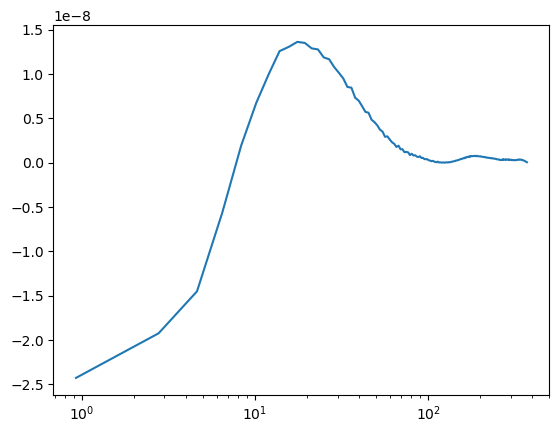

In [25]:
from matplotlib.gridspec import GridSpec
plt.semilogx(r/1e3,SF3/r,linewidth=1.5)
plt.semilogx(R/1e3,np.nanmean(SF3_L_lr+SF3_T_lr)/R,linewidth=1.5,marker='+')
plt.semilogx(R/1e3,np.nanmean(SF3_L_tb+SF3_T_tb)/R,linewidth=1.5,marker='+')

plt.grid(True)
plt.ylim([-1e-7,1e-7])

In [ ]:
Nlist=[10,20,50,100,150,200]
total_length=287
SF3_check=np.zeros(len(Nlist))
R_check=np.zeros(len(Nlist))
pos=0

for win in (Nlist):
    # print(win)
    SF3_check[pos],  _, _, _, _,R_check[pos]=check_SF3_largescale(u,v,xscale,total_length,win)
    pos=pos+1

In [26]:
Nlist=([2,4,6,8,10,20,30,50,75,100,125,150,175,200])
total_length=287
SF1_L_check=np.zeros(len(Nlist))
SF1_T_check=np.zeros(len(Nlist))
R_check=np.zeros(len(Nlist))
pos=0

for win in (Nlist):
    # print(win)
    print(f'{pos}')
    SF1_L_check[int(pos)], SF1_T_check[int(pos)],R_check[int(pos)]=check_SF1_largescale(u,v,xscale,total_length,win)
    pos=pos+1

0


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 286/286 [00:06<00:00, 45.82it/s]


1


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 284/284 [00:10<00:00, 28.01it/s]


2


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:05<00:00, 27.29it/s]


12


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 113/113 [00:04<00:00, 27.25it/s]


13


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:03<00:00, 27.05it/s]


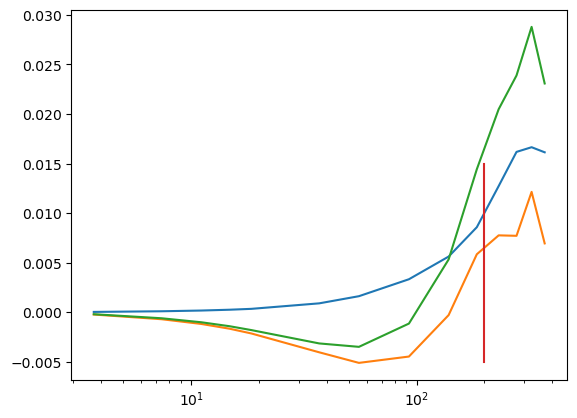

In [27]:
plt.semilogx(R_check/1e3,SF1_L_check,'')
plt.semilogx(R_check/1e3,SF1_T_check)
plt.semilogx(R_check/1e3,(SF1_T_check+SF1_L_check))
plt.plot([200,200],[-0.005,0.015])

In [28]:
SF1=SF1_T_check+SF1_L_check
sio.savemat('/meddy/simingzhang/Data/Figure_SF3/SF1_E_Hf.mat',{'SF1':SF1,'R_check':R_check})

In [ ]:
SF3_check.shape

Text(0.5, 1.0, 'Wave case: SF3/r')

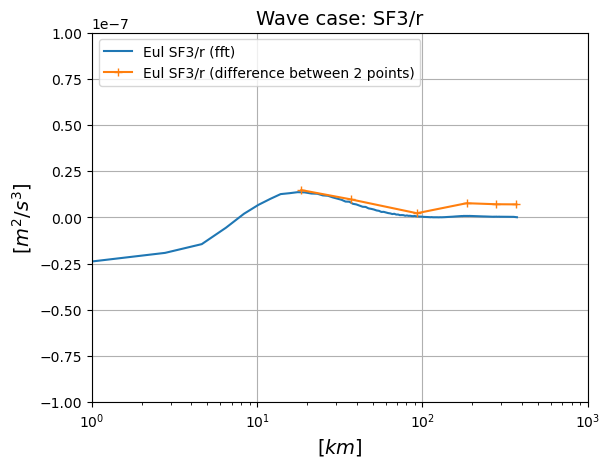

In [130]:
from matplotlib.gridspec import GridSpec
plt.semilogx(r/1e3,SF3/r,linewidth=1.5,label='Eul SF3/r (fft)')
plt.semilogx(R_check/1e3,SF3_check/R_check,linewidth=1.5,marker='+',label='Eul SF3/r (difference between 2 points)')
plt.grid(True)
plt.legend(loc=2)
plt.ylim([-1e-7,1e-7])
plt.xlim([1,1e3])
plt.xlabel('$[km]$',fontsize=14)
plt.ylabel('$[m^{2}/s^{3}]$',fontsize=14)
plt.title('Wave case: SF3/r',fontsize=14)

In [ ]:
sio.savemat('HF_SF3_check.mat',{'R_check':R_check,'SF3_check':SF3_check})

# SM

In [12]:
data_dir='/meddy/simingzhang/Data/RB_iceland_data/'
fname='iceland_no_wave/z_niskin2km_his_smooth_depth_500m_grd.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
files=data_dir+fname
print(files)
ds=xr.open_dataset(files)
ds

grid=xr.open_dataset(data_dir+'niskin2km_500m_grd.nc')
dx=1/grid['pm'].values
dy=1/grid['pn'].values
xscale=np.mean([dx,dy])
R=xscale*287

u=u2rho_3d(np.squeeze(ds['u'].values))
v=v2rho_3d(np.squeeze(ds['v'].values))

SM_SF3=sio.loadmat('SM_Eulerian_SF3.mat')
# SM_SF3
r=np.squeeze(SM_SF3['r'])
SF3_L=np.nanmean(np.squeeze(SM_SF3['S3L1_alltime']),axis=0)
SF3_T=np.nanmean(np.squeeze(SM_SF3['S3T1_alltime']),axis=0)
SF3=SF3_L+SF3_T
SF3.shape

Nlist=[10,20,50,100,150,200]
total_length=287
SF3_check=np.zeros(len(Nlist))
R_check=np.zeros(len(Nlist))
pos=0

for win in (Nlist):
    # print(win)
    SF3_check[pos],  _, _, _, _,R_check[pos]=check_SF3_largescale(u,v,xscale,total_length,win)
    pos=pos+1

/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/z_niskin2km_his_smooth_depth_500m_grd.0002.nc


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:08<00:00, 10.04it/s]


In [14]:
Nlist=([2,4,6,8,10,20,30,50,75,100,125,150,175,200])
total_length=287
SF1_L_check=np.zeros(len(Nlist))
SF1_T_check=np.zeros(len(Nlist))
R_check=np.zeros(len(Nlist))
pos=0

for win in (Nlist):
    # print(win)
    print(f'{pos}')
    SF1_L_check[int(pos)], SF1_T_check[int(pos)],R_check[int(pos)]=check_SF1_largescale(u,v,xscale,total_length,win)
    pos=pos+1

SF1=SF1_T_check+SF1_L_check
sio.savemat('/meddy/simingzhang/Data/Figure_SF3/SF1_E_Sm.mat',{'SF1':SF1,'R_check':R_check})

0


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 286/286 [00:07<00:00, 37.58it/s]


1


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 284/284 [00:08<00:00, 32.06it/s]


2


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:05<00:00, 26.50it/s]


12


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 113/113 [00:04<00:00, 27.51it/s]


13


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:03<00:00, 25.53it/s]


Text(0.5, 1.0, 'Nowave case: SF3/r')

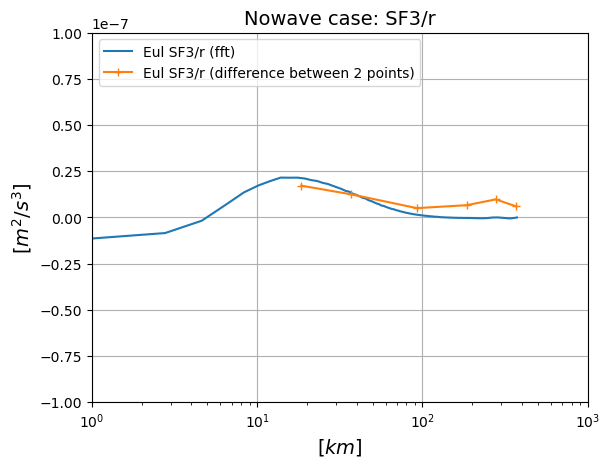

In [133]:
from matplotlib.gridspec import GridSpec
plt.semilogx(r/1e3,SF3/r,linewidth=1.5,label='Eul SF3/r (fft)')
plt.semilogx(R_check/1e3,SF3_check/R_check,linewidth=1.5,marker='+',label='Eul SF3/r (difference between 2 points)')
plt.grid(True)
plt.legend(loc=2)
plt.ylim([-1e-7,1e-7])
plt.xlim([1,1e3])
plt.xlabel('$[km]$',fontsize=14)
plt.ylabel('$[m^{2}/s^{3}]$',fontsize=14)
plt.title('Nowave case: SF3/r',fontsize=14)

In [135]:
sio.savemat('SM_SF3_check.mat',{'R_check':R_check,'SF3_check':SF3_check})